# Temporary Theoretical Bump RF Check

This temporary notebook checks whether the desired bump attractor is already too wide before running any simulation. It directly constructs theoretical `r_B(theta | x)` and computes single-neuron receptive fields over `x_E in [0, 1]`.

No simulation data are loaded. No smoothing is applied.

## Setup

Use the same geometry and `x -> theta` mapping as the rate model. The key parameter scanned here is `sigma_B`, the Gaussian width of the desired bump attractor in theta space.

In [3]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = Path('/projectnb/ecog-eeg/cyw6/CANN_DDM_rate_model')
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from rate_model_core.accumulator_simulation import _build_circuit_baseline_params
from rate_model_core.config import NeuralGeometryConfig, build_geometry

plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

In [17]:
BASELINE_PARAMS = _build_circuit_baseline_params(
    coherence=0.5,
    drift_gain=1.0,
    noise_scale=0.5,
    dt_ddm=5.0,
    t_start=10,
    dur=2000,
    max_time=2000,
    seed=201,
    kappa=1.0,
    theta_margin=0.02,
    x0=0.5,
    boundary=1.0,
    mar=0.01,
    c_eb=0.1,
)

GEOMETRY_PARAMS = BASELINE_PARAMS['geometry']
EDGE_PARAMS = BASELINE_PARAMS['edge_pop']
BUMP_PARAMS = BASELINE_PARAMS['bump_pop']

NUM_UNITS = int(GEOMETRY_PARAMS['num_units'])
CODING_LIMIT = float(GEOMETRY_PARAMS['coding_limit'])
CODING_FRAC = float(GEOMETRY_PARAMS['coding_frac'])
CLAMP_FRAC = float(GEOMETRY_PARAMS['clamp_frac'])
GAMMA_E = float(EDGE_PARAMS['gamma_E'])
BOUNDARY = 1.0
BASELINE_SIGMA_B = float(BUMP_PARAMS['sigma_B'])

SIGMA_B_VALUES = [0.05, 0.075, 0.1, 0.15, BASELINE_SIGMA_B, 0.45]
SIGMA_B_VALUES = sorted(set(float(v) for v in SIGMA_B_VALUES))
SELECTED_NEURON_INDICES = np.arange(463, 554, dtype=int)
BUMP_EXAMPLE_INDICES = [465, 485, 505, 525]
X_GRID = np.linspace(0.0, 1.0, 401)

geometry = build_geometry(
    NeuralGeometryConfig(
        num_units=NUM_UNITS,
        coding_limit=CODING_LIMIT,
        coding_frac=CODING_FRAC,
        clamp_frac=CLAMP_FRAC,
    )
)

theta = geometry.theta_min + np.arange(NUM_UNITS) / (NUM_UNITS - 1) * (geometry.theta_max - geometry.theta_min)
selected_theta = theta[SELECTED_NEURON_INDICES]

def evidence_to_pos_np(x, boundary=BOUNDARY, theta_max=geometry.coding_theta_max, s=GAMMA_E):
    x = np.asarray(x, dtype=float)
    theta_min = -theta_max
    interval = theta_max - theta_min
    normalization = 1.0 - np.exp(-s * interval)
    clipped = np.clip(x, 0.0, boundary)
    interior = theta_min - np.log(1.0 - (clipped / boundary) * normalization) / s
    return np.where(x <= 0.0, theta_min, np.where(x >= boundary, theta_max, interior))

def theoretical_bump_rf(theta_units, x_grid, sigma_b):
    centers = evidence_to_pos_np(x_grid)
    theta_rel = theta_units[:, None] - centers[None, :]
    return np.exp(-0.5 * (theta_rel / float(sigma_b)) ** 2)

theta_centers = evidence_to_pos_np(X_GRID)

print('baseline geometry:', GEOMETRY_PARAMS)
print('baseline edge params:', EDGE_PARAMS)
print('baseline bump params:', BUMP_PARAMS)
print('coding theta_min/theta_max:', float(geometry.coding_theta_min), float(geometry.coding_theta_max))
print('selected neuron range:', int(SELECTED_NEURON_INDICES[0]), int(SELECTED_NEURON_INDICES[-1]))
for idx in BUMP_EXAMPLE_INDICES:
    print(f'neuron {idx}: theta={theta[idx]:.4f}')

baseline geometry: {'num_units': 1024, 'coding_limit': 1.5707963267948966, 'coding_frac': 0.2, 'clamp_frac': 0.1}
baseline edge params: {'tau_E': 1, 'alpha_E': 1.0, 'gamma_E': 1.1, 'edge_type': 'tanh', 'offset': 0.0, 'c_EB': 0.1, 'optimize_offset': False, 'noise_scale_edge': 0.0}
baseline bump params: {'tau_B': 0.15, 'beta_B': 6.0, 'c_BE_params': {'mode': 'target_diffusion', 'theta_margin': 0.02, 'kappa': 1.0}, 'sigma_B': 0.2, 'noise_scale_bump': 0.0}
coding theta_min/theta_max: -1.5707963267948966 1.5707963267948966
selected neuron range: 463 553
neuron 465: theta=-0.7140
neuron 485: theta=-0.4069
neuron 505: theta=-0.0998
neuron 525: theta=0.2073


## Figure 1: Canonical Bump Profiles in Theta Space

This shows the attractor profile itself for different `sigma_B` values. If the canonical profile is very wide at `sigma_B=0.25`, broad RFs are expected even before simulation.

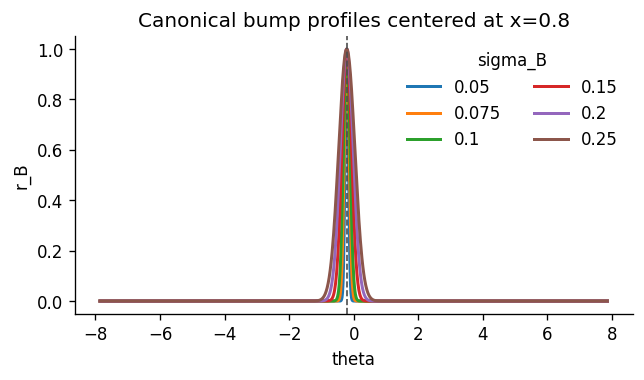

In [12]:
center_x = 0.8
center_theta = float(evidence_to_pos_np(center_x))
fig, ax = plt.subplots(figsize=(6.0, 3.0))
for sigma_b in SIGMA_B_VALUES:
    profile = np.exp(-0.5 * ((theta - center_theta) / sigma_b) ** 2)
    ax.plot(theta, profile, linewidth=1.8, label=f'{sigma_b:g}')
ax.axvline(center_theta, color='0.3', linestyle='--', linewidth=1.0)
ax.set_xlabel('theta')
ax.set_ylabel('r_B')
ax.set_title(f'Canonical bump profiles centered at x={center_x:g}')
ax.legend(frameon=False, title='sigma_B', ncol=2)
plt.show()

## Figure 2: Theoretical Example-Neuron RFs over x

Each subplot is one `sigma_B`. Lines are the chosen bump neurons. These are raw theoretical RFs, not smoothed.

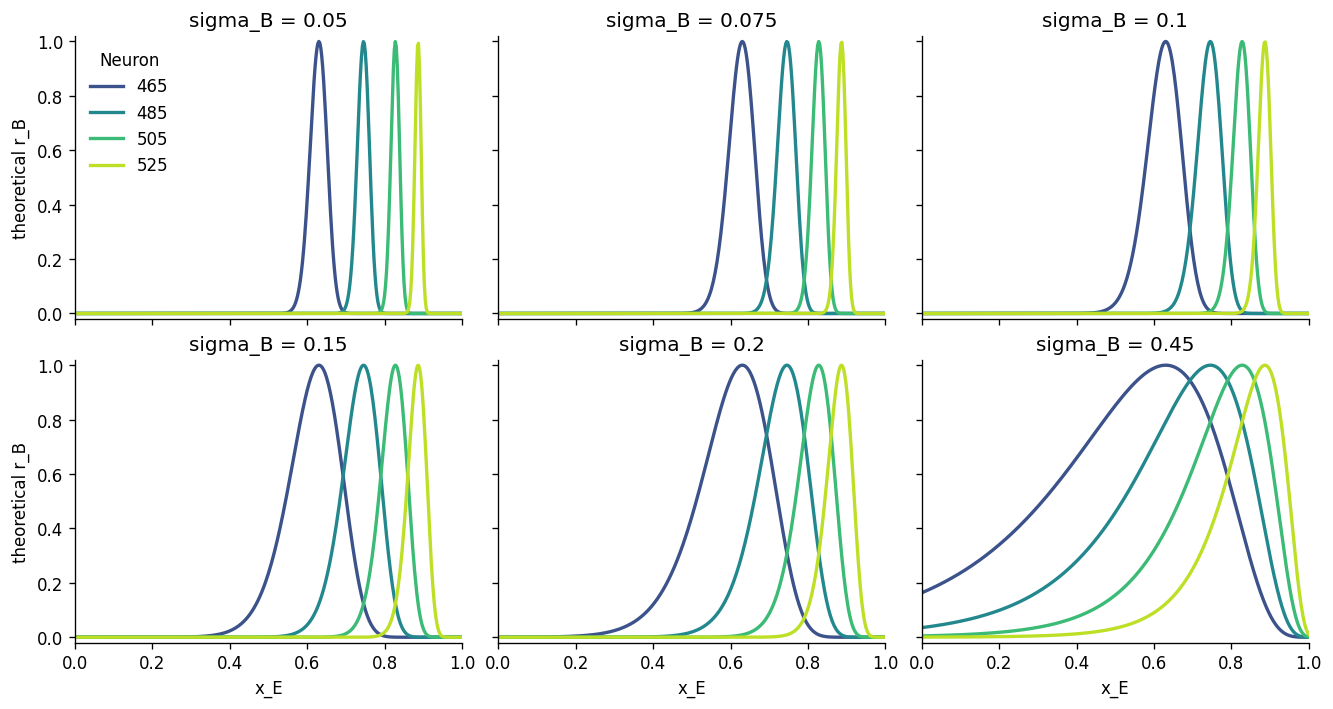

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(11.0, 5.8), sharex=True, sharey=True, constrained_layout=True)
axes = axes.ravel()
colors = plt.cm.viridis(np.linspace(0.25, 0.9, len(BUMP_EXAMPLE_INDICES)))
for ax, sigma_b in zip(axes, SIGMA_B_VALUES):
    rf_all = theoretical_bump_rf(theta, X_GRID, sigma_b)
    for color, idx in zip(colors, BUMP_EXAMPLE_INDICES):
        ax.plot(X_GRID, rf_all[idx], color=color, linewidth=2.0, label=str(idx))
    ax.set_title(f'sigma_B = {sigma_b:g}')
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.02, 1.02)
for ax in axes[3:]:
    ax.set_xlabel('x_E')
for ax in axes[::3]:
    ax.set_ylabel('theoretical r_B')
axes[0].legend(frameon=False, title='Neuron', loc='upper left')
plt.show()

## Figure 3: Theoretical RF Heatmaps for Neurons 493-553

A localized bump code should appear as a narrow diagonal band. A broad attractor will smear this band and can make many neurons look ramp-like over `x`.

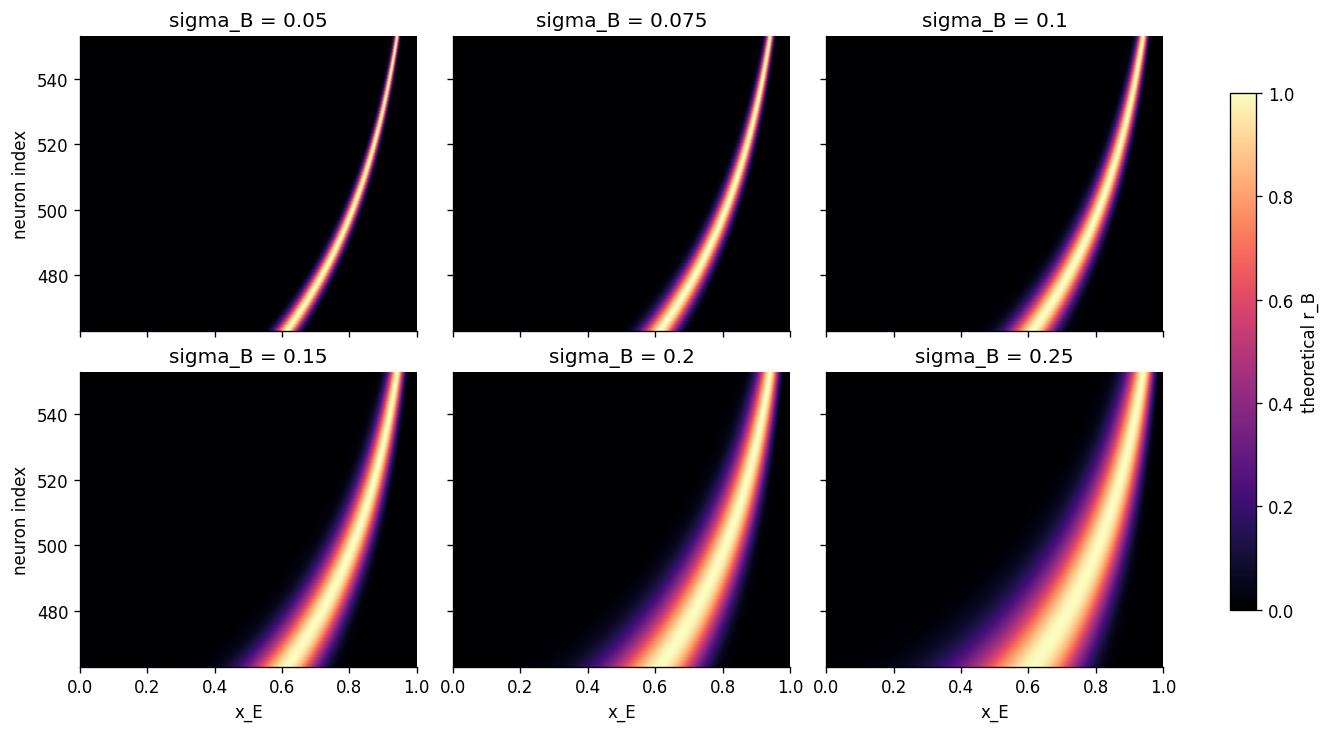

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(11.0, 6.0), sharex=True, sharey=True, constrained_layout=True)
axes = axes.ravel()
for ax, sigma_b in zip(axes, SIGMA_B_VALUES):
    rf_selected = theoretical_bump_rf(selected_theta, X_GRID, sigma_b)
    im = ax.imshow(
        rf_selected,
        aspect='auto',
        origin='lower',
        extent=[X_GRID[0], X_GRID[-1], SELECTED_NEURON_INDICES[0], SELECTED_NEURON_INDICES[-1]],
        vmin=0,
        vmax=1,
        cmap='magma',
    )
    ax.set_title(f'sigma_B = {sigma_b:g}')
for ax in axes[3:]:
    ax.set_xlabel('x_E')
for ax in axes[::3]:
    ax.set_ylabel('neuron index')
fig.colorbar(im, ax=axes, shrink=0.82, label='theoretical r_B')
plt.show()

## Figure 4: Tail/Peak Diagnostics

For each example neuron and `sigma_B`, this quantifies how much off-peak tail remains near `x < 0.1` and `x > 0.9`. Smaller tail/peak ratios indicate more localized RFs.

,sigma_B,neuron,theta,peak,x_peak,left_tail_mean_x_lt_0p1,right_tail_mean_x_gt_0p9,max_tail_over_peak,right_tail_over_peak
0,0.050,538,0.406902,0.998645,0.9150,1.033915e-311,0.158371,0.158586,0.158586
1,0.050,543,0.483676,0.999598,0.9250,0.000000e+00,0.148760,0.148820,0.148820
2,0.050,548,0.560450,0.981475,0.9325,0.000000e+00,0.136738,0.139319,0.139319
3,0.050,553,0.637224,0.983048,0.9425,0.000000e+00,0.125665,0.127832,0.127832
4,0.075,538,0.406902,0.999398,0.9150,1.302338e-139,0.219575,0.219708,0.219708
5,0.075,543,0.483676,0.999822,0.9250,4.870893e-151,0.221340,0.221379,0.221379
6,0.075,548,0.560450,0.991724,0.9325,6.397869e-163,0.205412,0.207126,0.207126
7,0.075,553,0.637224,0.992430,0.9425,2.950907e-175,0.188853,0.190293,0.190293
8,0.100,538,0.406902,0.999661,0.9150,2.940656e-79,0.267340,0.267431,0.267431
9,0.100,543,0.483676,0.999900,0.9250,1.079814e-85,0.285362,0.285390,0.285390


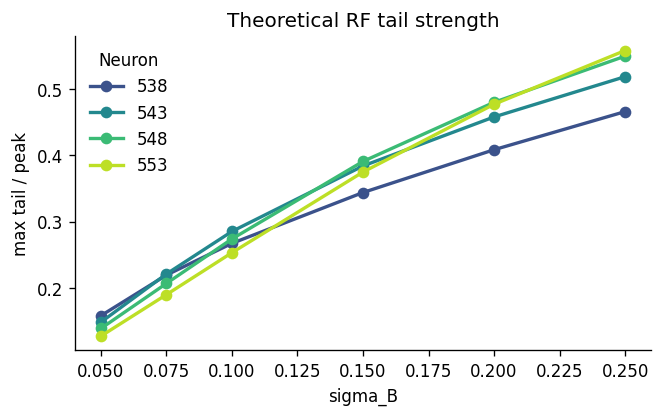

In [6]:
rows = []
left_mask = X_GRID < 0.1
right_mask = X_GRID > 0.9
for sigma_b in SIGMA_B_VALUES:
    rf_all = theoretical_bump_rf(theta, X_GRID, sigma_b)
    for idx in BUMP_EXAMPLE_INDICES:
        rf = rf_all[idx]
        peak = float(np.max(rf))
        x_peak = float(X_GRID[int(np.argmax(rf))])
        left_tail = float(np.mean(rf[left_mask]))
        right_tail = float(np.mean(rf[right_mask]))
        rows.append({
            'sigma_B': float(sigma_b),
            'neuron': int(idx),
            'theta': float(theta[idx]),
            'peak': peak,
            'x_peak': x_peak,
            'left_tail_mean_x_lt_0p1': left_tail,
            'right_tail_mean_x_gt_0p9': right_tail,
            'max_tail_over_peak': max(left_tail, right_tail) / peak if peak > 0 else np.nan,
            'right_tail_over_peak': right_tail / peak if peak > 0 else np.nan,
        })

diagnostics = pd.DataFrame(rows)
display(diagnostics)

fig, ax = plt.subplots(figsize=(6.2, 3.4))
for color, idx in zip(colors, BUMP_EXAMPLE_INDICES):
    df = diagnostics[diagnostics['neuron'] == idx]
    ax.plot(df['sigma_B'], df['max_tail_over_peak'], marker='o', linewidth=2.0, color=color, label=str(idx))
ax.set_xlabel('sigma_B')
ax.set_ylabel('max tail / peak')
ax.set_title('Theoretical RF tail strength')
ax.legend(frameon=False, title='Neuron')
plt.show()

## Interpretation Guide

- If `sigma_B=0.25` already gives broad RFs and high tail/peak ratios, the desired bump attractor is too wide for localized RF display.
- If `sigma_B=0.05` or `0.1` gives clean localized RFs, those are the first candidates for a minimal simulation scan.
- If even small `sigma_B` does not give localized theoretical RFs for these neurons, the issue is likely neuron-position selection or the nonlinear `theta -> x` mapping, not simulation instability.